In [44]:

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
from collections import Counter
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
warnings.filterwarnings('ignore')

# Configurações globais do pipeline
CONFIG = {
    # Modelo leve (~90MB) e eficiente para português
    "embedding_model": "paraphrase-multilingual-MiniLM-L12-v2",
    
    # DBSCAN: distância máxima entre pontos do mesmo cluster
    # (em espaço de cosseno: 0 = idêntico, 1 = oposto)
    # Ajuste conforme a variabilidade das suas descrições
    "dbscan_eps": 0.25,
    
    # Mínimo de amostras para formar um cluster core
    "dbscan_min_samples": 2,
    
    # Limiares de decisão
    "limiar_cluster_dominante": 0.70,  # >= 70% no maior cluster → enviar para LLM
    "limiar_outlier_alto": 0.50,       # >= 50% de outliers → GTIN ruidoso
    "min_descricoes_por_gtin": 3,      # GTINs com < N descrições → passagem direta
}

print("✓ Configurações carregadas.")
print(f"  Modelo: {CONFIG['embedding_model']}")
print(f"  DBSCAN eps={CONFIG['dbscan_eps']}, min_samples={CONFIG['dbscan_min_samples']}")


✓ Configurações carregadas.
  Modelo: paraphrase-multilingual-MiniLM-L12-v2
  DBSCAN eps=0.25, min_samples=2


## 1. Carregamento e Inspeção dos Dados

In [45]:
df_789 = pd.read_csv('./data/gtin_789_validacao.csv')
df_789.info()

<class 'pandas.DataFrame'>
RangeIndex: 215135 entries, 0 to 215134
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        215135 non-null  int64  
 1   data              215135 non-null  str    
 2   gtin              215135 non-null  int64  
 3   ncm               215135 non-null  int64  
 4   des_item_norm     215133 non-null  str    
 5   unidade           215135 non-null  str    
 6   valor_unit_liq    215135 non-null  float64
 7   qtd_geral_item    215135 non-null  object 
 8   qtd_reg_consolid  215135 non-null  int64  
dtypes: float64(1), int64(4), object(1), str(3)
memory usage: 14.8+ MB


In [46]:
# Inspecionar as variáveis financeiras
print("=== valor_unit_liq ===")
print(df_789['valor_unit_liq'].describe())

print("\n=== qtd_geral_item ===")
print(pd.to_numeric(df_789['qtd_geral_item'], errors='coerce').describe())

print("\n=== qtd_reg_consolid ===")
print(df_789['qtd_reg_consolid'].describe())

print("\n=== Amostra de 10 linhas ===")
print(df_789[['gtin', 'valor_unit_liq', 'qtd_geral_item', 'qtd_reg_consolid']].sample(10).to_string(index=False))


=== valor_unit_liq ===
count    215135.000000
mean         11.511400
std          20.868301
min           0.000000
25%           3.790000
50%           6.980000
75%          12.990000
max        3790.000000
Name: valor_unit_liq, dtype: float64

=== qtd_geral_item ===
count    2.151330e+05
mean     7.113988e+01
std      4.269231e+03
min      1.000000e-02
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      1.658017e+06
Name: qtd_geral_item, dtype: float64

=== qtd_reg_consolid ===
count    215135.000000
mean          3.867111
std          13.986155
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        2561.000000
Name: qtd_reg_consolid, dtype: float64

=== Amostra de 10 linhas ===
         gtin  valor_unit_liq qtd_geral_item  qtd_reg_consolid
7891991014908            2.49            1.0                 1
7891025021117            3.29            1.0                 1
7896304100439            6.99            2.0       

## 2. Análise Exploratória — Volume Financeiro e Distribuição de Descrições

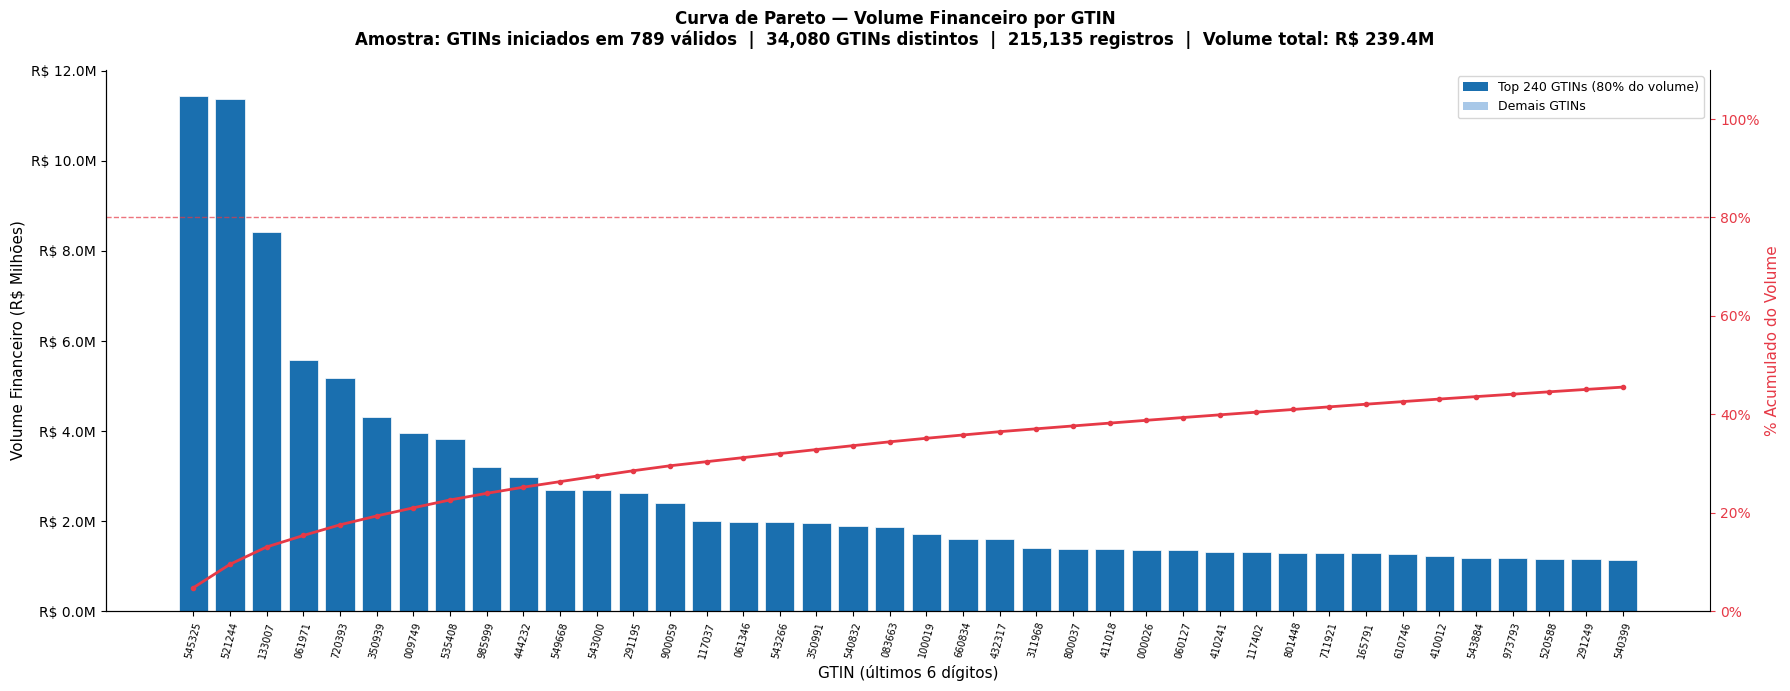


Top 10 GTINs por Volume Financeiro:
         gtin     volume_total   pct pct_acum  n_registros    qtd_total
7890316545325 R$ 11,450,831.11 4.78%    4.78%           82 1032303.9200
7899050521244 R$ 11,382,507.89 4.75%    9.54%            6 1873813.8100
7897571133007  R$ 8,422,152.05 3.52%   13.05%            2  766451.0000
7898297061971  R$ 5,575,909.62 2.33%   15.38%           28  576467.5883
7896419720393  R$ 5,181,653.01 2.16%   17.55%            3  401986.3400
7898227350939  R$ 4,306,552.32 1.80%   19.35%           52  144343.6800
7894904009749  R$ 3,960,616.05 1.65%   21.00%          100  163645.8799
7897318535408  R$ 3,821,780.41 1.60%   22.60%          150   84328.6034
7894904985999  R$ 3,212,725.26 1.34%   23.94%            6  292874.0000
7893000444232  R$ 2,987,967.06 1.25%   25.19%           72  115307.3791
7890316549668  R$ 2,702,024.87 1.13%   26.32%            7  112140.5800
7890316543000  R$ 2,688,090.74 1.12%   27.44%            6  124218.0000
7898302291195  R$ 2,621,940

In [47]:

# --- Cálculo do volume financeiro ---
df_789['qtd_geral_item'] = pd.to_numeric(df_789['qtd_geral_item'], errors='coerce')

df_789['volume_financeiro'] = df_789['valor_unit_liq'] * df_789['qtd_geral_item']

volume_por_gtin = (
    df_789.groupby('gtin')
    .agg(
        volume_total=('volume_financeiro', 'sum'),
        n_registros=('gtin', 'count'),
        qtd_total=('qtd_geral_item', 'sum'),
    )
    .reset_index()
    .sort_values('volume_total', ascending=False)
)

volume_por_gtin['pct']     = volume_por_gtin['volume_total'] / volume_por_gtin['volume_total'].sum() * 100
volume_por_gtin['pct_acum'] = volume_por_gtin['pct'].cumsum()

# Top N que representam 80% do volume
top_80 = volume_por_gtin[volume_por_gtin['pct_acum'] <= 80]
n_top  = len(top_80)

# Limita exibição para top 40 (visual)
top_plot = volume_por_gtin.head(40).copy()
top_plot['gtin_label'] = top_plot['gtin'].astype(str).str[-6:]  # últimos 6 dígitos

total_volume    = volume_por_gtin['volume_total'].sum()
total_gtins     = volume_por_gtin['gtin'].nunique()
total_registros = len(df_789)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(18, 7))

cores = ['#1a6faf' if i < n_top else '#a8c8e8' for i in range(len(top_plot))]
bars  = ax1.bar(range(len(top_plot)), top_plot['volume_total'] / 1e6,
                color=cores, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('Volume Financeiro (R$ Milhões)', fontsize=11)
ax1.set_xlabel('GTIN (últimos 6 dígitos)', fontsize=11)
ax1.set_xticks(range(len(top_plot)))
ax1.set_xticklabels(top_plot['gtin_label'], rotation=75, fontsize=7)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:.1f}M'))
ax1.spines[['top', 'right']].set_visible(False)

# Curva de Pareto
ax2 = ax1.twinx()
ax2.plot(range(len(top_plot)), top_plot['pct_acum'],
         color='#e63946', linewidth=2, marker='o', markersize=3, label='% Acumulado')
ax2.axhline(80, color='#e63946', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_ylabel('% Acumulado do Volume', fontsize=11, color='#e63946')
ax2.tick_params(axis='y', colors='#e63946')
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.spines[['top']].set_visible(False)

# Linha vertical do ponto de 80%
if n_top <= len(top_plot):
    ax1.axvline(n_top - 0.5, color='#e63946', linestyle=':', linewidth=1.5, alpha=0.8)
    ax1.text(n_top - 0.5 + 0.3, ax1.get_ylim()[1] * 0.92,
             f'{n_top} GTINs\n= 80% do volume', fontsize=8, color='#e63946')

# Legenda de cores
from matplotlib.patches import Patch
legenda = [
    Patch(facecolor='#1a6faf', label=f'Top {n_top} GTINs (80% do volume)'),
    Patch(facecolor='#a8c8e8', label='Demais GTINs'),
]
ax1.legend(handles=legenda, loc='upper right', fontsize=9)

# Título e metadados
fig.suptitle(
    f'Curva de Pareto — Volume Financeiro por GTIN\n'
    f'Amostra: GTINs iniciados em 789 válidos  |  '
    f'{total_gtins:,} GTINs distintos  |  '
    f'{total_registros:,} registros  |  '
    f'Volume total: R$ {total_volume/1e6:.1f}M',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('pareto_volume_financeiro_gtin.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Tabela resumo top 10 ---
print("\nTop 10 GTINs por Volume Financeiro:")
print(
    volume_por_gtin.head(20)[['gtin','volume_total','pct','pct_acum','n_registros','qtd_total']]
    .assign(volume_total=lambda x: x['volume_total'].map('R$ {:,.2f}'.format),
            pct=lambda x: x['pct'].map('{:.2f}%'.format),
            pct_acum=lambda x: x['pct_acum'].map('{:.2f}%'.format))
    .to_string(index=False)
)


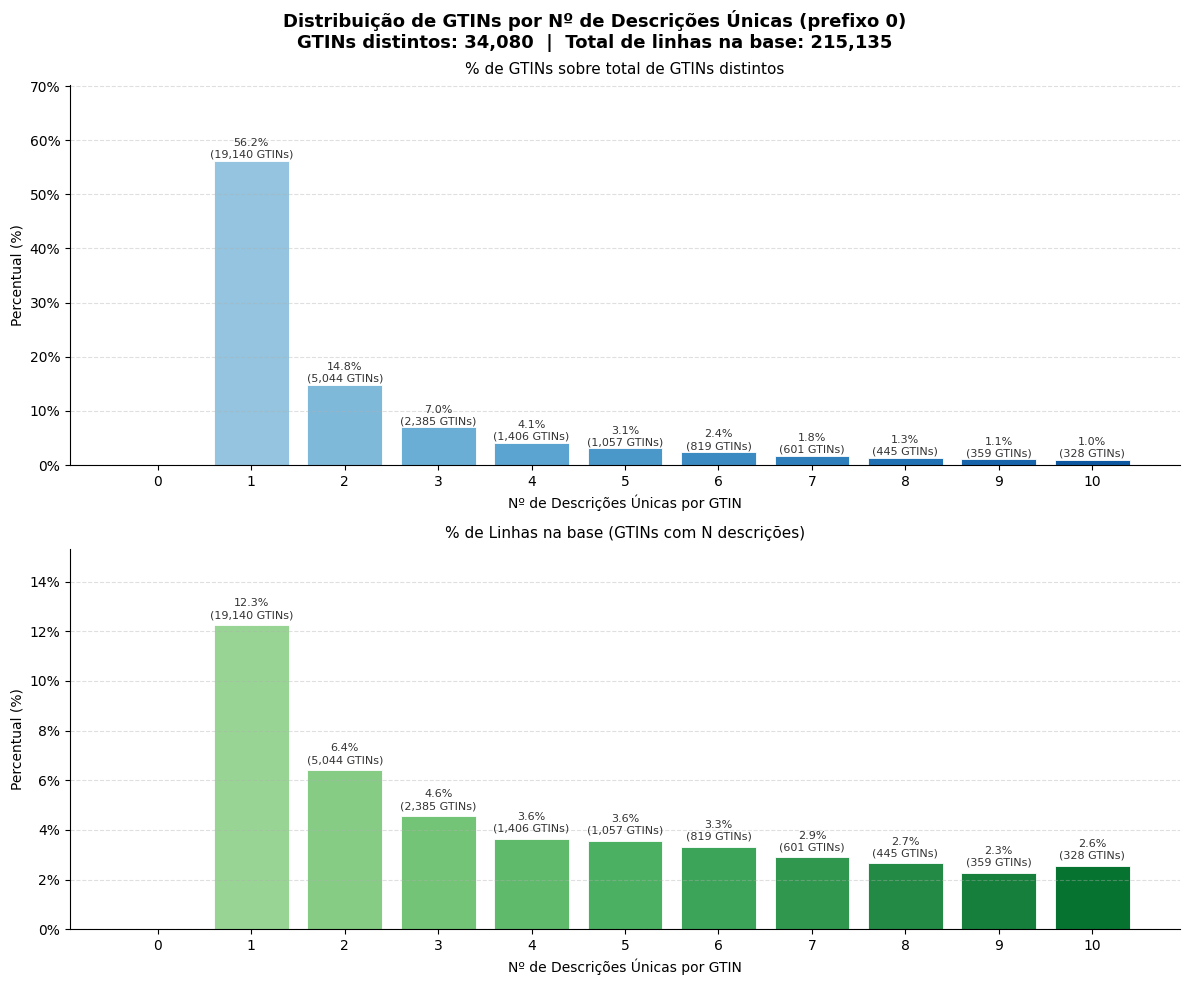

In [48]:
desc_por_gtin_0 = df_789.groupby('gtin').agg(
    n_desc_unicas=('des_item_norm', 'nunique'),
    n_registros=('des_item_norm', 'count')
).reset_index()

agrupado = desc_por_gtin_0.groupby('n_desc_unicas').agg(
    n_gtins=('gtin', 'count'),
    n_linhas=('n_registros', 'sum')
).reset_index()

agrupado = agrupado[agrupado['n_desc_unicas'] <= 10].copy()

total_gtins  = desc_por_gtin_0['gtin'].nunique()
total_linhas = len(df_789)

agrupado['pct_gtins']  = agrupado['n_gtins']  / total_gtins  * 100
agrupado['pct_linhas'] = agrupado['n_linhas'] / total_linhas * 100

x_pos = np.arange(len(agrupado))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle(
    f'Distribuição de GTINs por Nº de Descrições Únicas (prefixo 0)\n'
    f'GTINs distintos: {total_gtins:,}  |  Total de linhas na base: {total_linhas:,}',
    fontsize=13, fontweight='bold'
)

for ax, col_pct, titulo, cmap in zip(
    axes,
    ['pct_gtins', 'pct_linhas'],
    ['% de GTINs sobre total de GTINs distintos',
     '% de Linhas na base (GTINs com N descrições)'],
    [plt.cm.Blues, plt.cm.Greens]
):
    cores_ax = cmap(np.linspace(0.35, 0.85, len(agrupado)))
    bars = ax.bar(x_pos, agrupado[col_pct], color=cores_ax, edgecolor='white', linewidth=0.6)

    for bar, pct, n_gtins in zip(bars, agrupado[col_pct], agrupado['n_gtins']):
        if pct >= 0.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                f'{pct:.1f}%\n({n_gtins:,.0f} GTINs)',
                ha='center', va='bottom', fontsize=8, color='#333333'
            )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(agrupado['n_desc_unicas'].astype(str))
    ax.set_xlabel('Nº de Descrições Únicas por GTIN', fontsize=10)
    ax.set_ylabel('Percentual (%)', fontsize=10)
    ax.set_ylim(0, agrupado[col_pct].max() * 1.25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_title(titulo, fontsize=11, pad=8)

plt.tight_layout()
plt.savefig('distribuicao_gtins_0_descricoes.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Construção da Amostra de Trabalho

Critérios aplicados em sequência:

1. **Top por volume financeiro** — selecionar os GTINs que representam ~80% do volume total (calculado sobre a base completa)
2. **Mínimo de descrições** — remover GTINs com menos de 3 descrições únicas dentro dessa seleção (insuficientes para clustering)

In [53]:
# ── Passo 1: Top GTINs por volume financeiro (≈ 80% do volume) ──────────────
top_gtins_volume = volume_por_gtin[volume_por_gtin['pct_acum'] <= 95]['gtin'].values

df_amostra = df_789[df_789['gtin'].isin(top_gtins_volume)].copy()

print(f"Passo 1 — Top por volume financeiro")
print(f"  GTINs selecionados : {df_amostra['gtin'].nunique():,}")
print(f"  Registros          : {len(df_amostra):,}")
print(f"  Volume representado: {df_amostra['volume_financeiro'].sum() / df_789['volume_financeiro'].sum() * 100:.1f}% do total")

Passo 1 — Top por volume financeiro
  GTINs selecionados : 826
  Registros          : 21,567
  Volume representado: 95.0% do total


In [54]:
# ── Passo 2: Filtrar GTINs com >= 3 descrições únicas ───────────────────────
desc_por_gtin_amostra = df_amostra.groupby('gtin')['des_item_norm'].nunique()
gtins_ok = desc_por_gtin_amostra[desc_por_gtin_amostra >= 3].index

df_amostra = df_amostra[df_amostra['gtin'].isin(gtins_ok)].copy()

print(f"Passo 2 — Mínimo de 3 descrições únicas")
print(f"  GTINs mantidos     : {df_amostra['gtin'].nunique():,}")
print(f"  Registros          : {len(df_amostra):,}")
print(f"  Volume representado: {df_amostra['volume_financeiro'].sum() / df_789['volume_financeiro'].sum() * 100:.1f}% do total")

# ── Validação final ──────────────────────────────────────────────────────────
falhos = desc_por_gtin_amostra[desc_por_gtin_amostra < 3]
if len(falhos) == 0:
    print("\n✓ Todos os GTINs possuem >= 3 descrições únicas.")
else:
    print(f"\n⚠️  {len(falhos)} GTINs com < 3 descrições removidos.")

# ── Salvar ───────────────────────────────────────────────────────────────────
df_amostra.to_csv('./data/amostra_gtin_789.csv', index=False)
print(f"✓ Amostra salva em ./data/amostra_gtin_789.csv")

Passo 2 — Mínimo de 3 descrições únicas
  GTINs mantidos     : 309
  Registros          : 20,133
  Volume representado: 43.5% do total

⚠️  517 GTINs com < 3 descrições removidos.
✓ Amostra salva em ./data/amostra_gtin_789.csv


## 4. Pipeline de Clustering por GTIN

| Etapa | Descrição |
|---|---|
| Vetorização | Embeddings com `sentence-transformers` |
| Clustering | DBSCAN por GTIN |
| Pureza | Métrica de qualidade por GTIN |
| Decisão | Roteamento: LLM / revisão manual / descarte |